In [50]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio

In [ ]:
data = sio.loadmat("data/ex6_ImagData2Load.mat")
ImgT1 = data['ImgT1']
ImgT2 = data['ImgT2']
ROI_GM = data['ROI_GM'].astype(bool)
ROI_WM = data['ROI_WM'].astype(bool)

Text(0.5, 1.0, 'ImgT2')

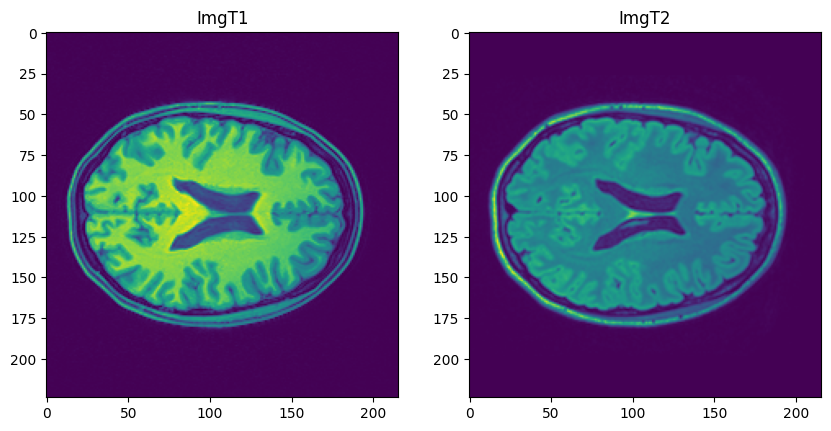

In [52]:
plt.figure(figsize=(10, 10))
plt.subplot(1, 2, 1)
plt.imshow(ImgT1)
plt.title('ImgT1')
plt.subplot(1, 2, 2)
plt.imshow(ImgT2)
plt.title('ImgT2')

The two MRI image modalities contain different types of intensity classes:

(Orange): The White Matter (WM) is the tissue type that contain the brain network - like the cables in the internet. The WM ensure the communication flow between functional brain regions.
(Yellow): The Grey Matter (GM) is the tissue type that contain the cell bodies at the end of the brain network and are the functional units in the brain. The functional units are like CPUs in the computer. They are processing our sensorial input and are determining a reacting to these. It could be to start running.
(Magenta): Cerebrospinal fluid (CSF) which is the water in the brain
(Green): Background of the image

https://medium.com/@susanne.schmid/image-normalization-in-medical-imaging-f586c8526bd1

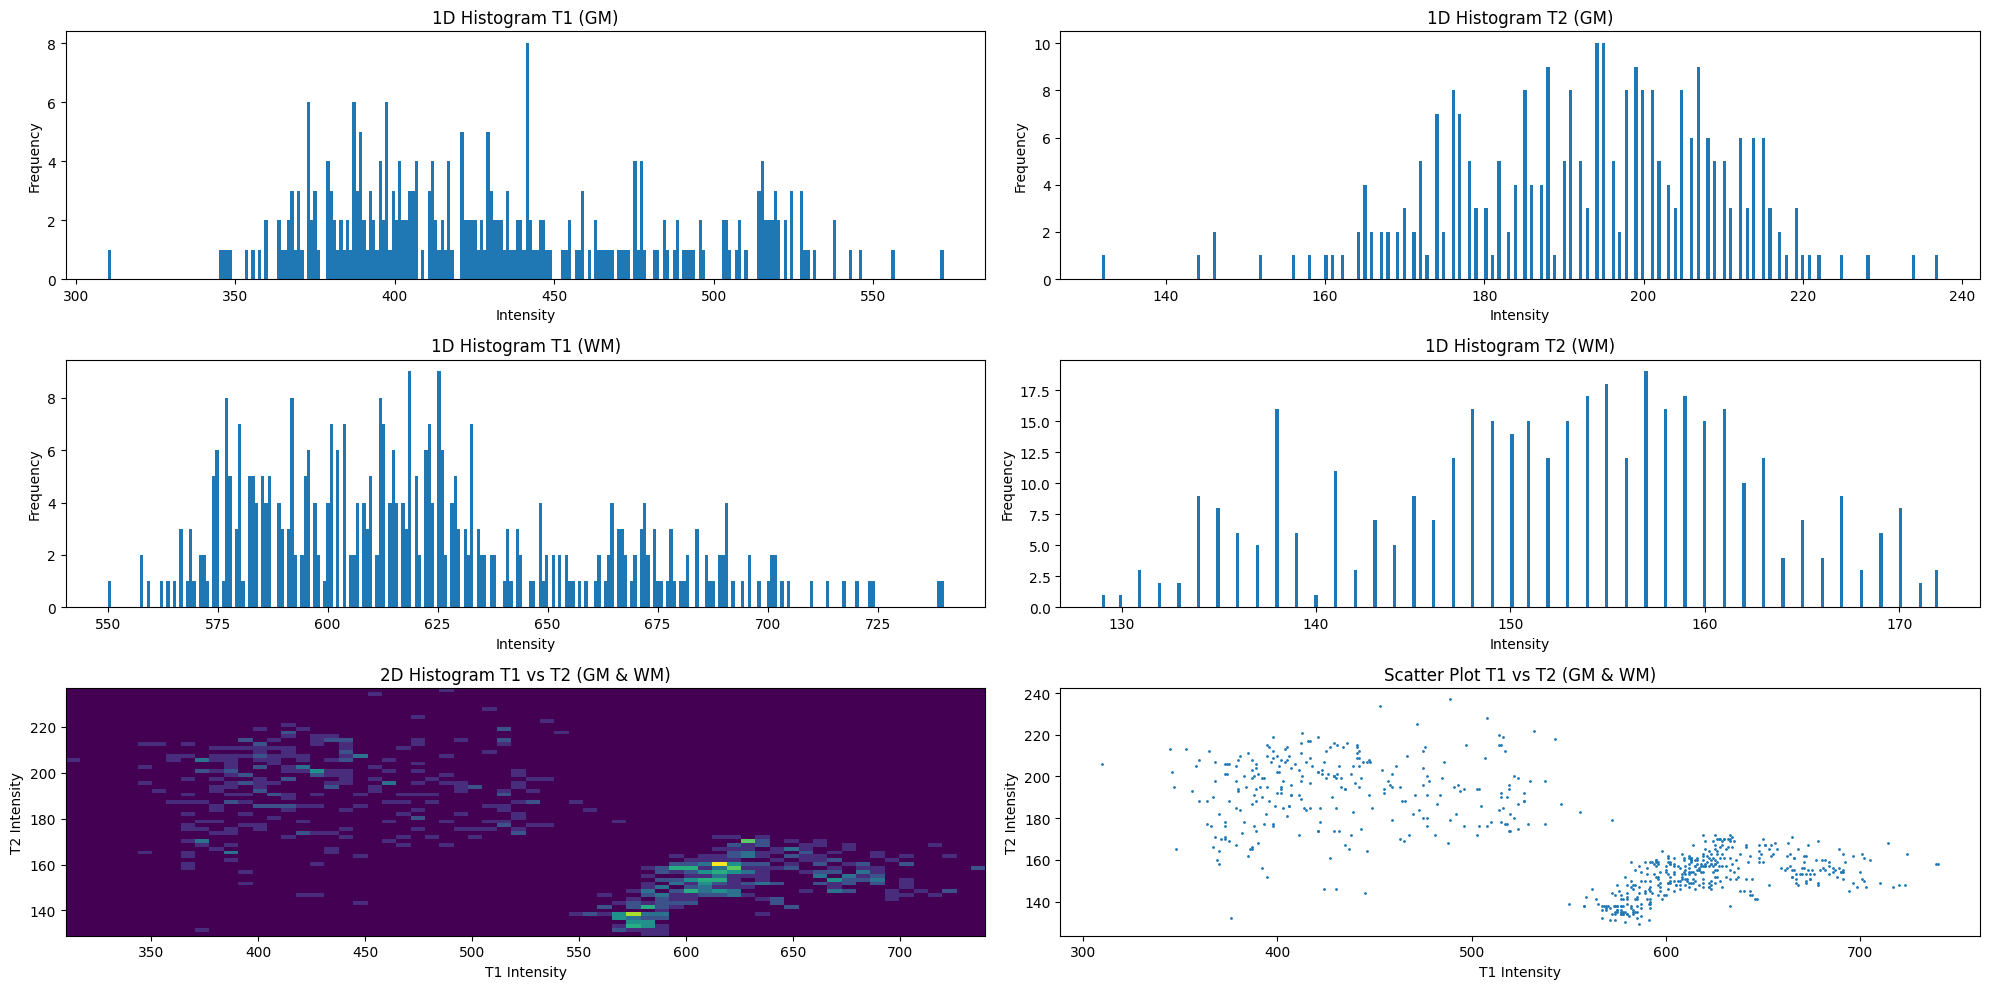

In [53]:
fig, axes = plt.subplots(3, 2, figsize=(20, 10))

t1_data = ImgT1[ROI_GM | ROI_WM]
t2_data = ImgT2[ROI_GM | ROI_WM]
# 1D Histogram for T1 (excluding background and WM)
t1_gm_data = ImgT1[ROI_GM]  # Exclude background voxels
axes[0, 0].hist(t1_gm_data.ravel(), bins=256)
axes[0, 0].set_title('1D Histogram T1 (GM)')
axes[0, 0].set_xlabel('Intensity')
axes[0, 0].set_ylabel('Frequency')

# 1D Histogram for T2 (excluding background and WM)
t2_gm_data = ImgT2[ROI_GM]
axes[0, 1].hist(t2_gm_data.ravel(), bins=256)
axes[0, 1].set_title('1D Histogram T2 (GM)')
axes[0, 1].set_xlabel('Intensity')
axes[0, 1].set_ylabel('Frequency')

# 1D Histogram for T1 (excluding background and GM)
t1_wm_data = ImgT1[ROI_WM]  # Exclude background voxels
axes[1, 0].hist(t1_wm_data.ravel(), bins=256)
axes[1, 0].set_title('1D Histogram T1 (WM)')
axes[1, 0].set_xlabel('Intensity')
axes[1, 0].set_ylabel('Frequency')

# 1D Histogram for T2 (excluding background)
t2_wm_data = ImgT2[ROI_WM]
axes[1, 1].hist(t2_wm_data.ravel(), bins=256)
axes[1, 1].set_title('1D Histogram T2 (WM)')
axes[1, 1].set_xlabel('Intensity')
axes[1, 1].set_ylabel('Frequency')

# 2D Histogram for T1 and T2 (excluding background)
axes[2, 0].hist2d(t1_data.ravel(), t2_data.ravel(), bins=64)
axes[2, 0].set_title('2D Histogram T1 vs T2 (GM & WM)')
axes[2, 0].set_xlabel('T1 Intensity')
axes[2, 0].set_ylabel('T2 Intensity')


# Scatter plot for T1 and T2 (excluding background)
axes[2, 1].scatter(t1_data.ravel(), t2_data.ravel(), s=1) # s controls marker size
axes[2, 1].set_title('Scatter Plot T1 vs T2 (GM & WM)')
axes[2, 1].set_xlabel('T1 Intensity')
axes[2, 1].set_ylabel('T2 Intensity')

plt.tight_layout()
plt.show()


What is the intensity threshold that can separate the GM and WM classes (roughly) from the 1D histograms?

T1 575
T2 180


In [54]:
ROI_WM.shape, ROI_GM.shape

((224, 216), (224, 216))

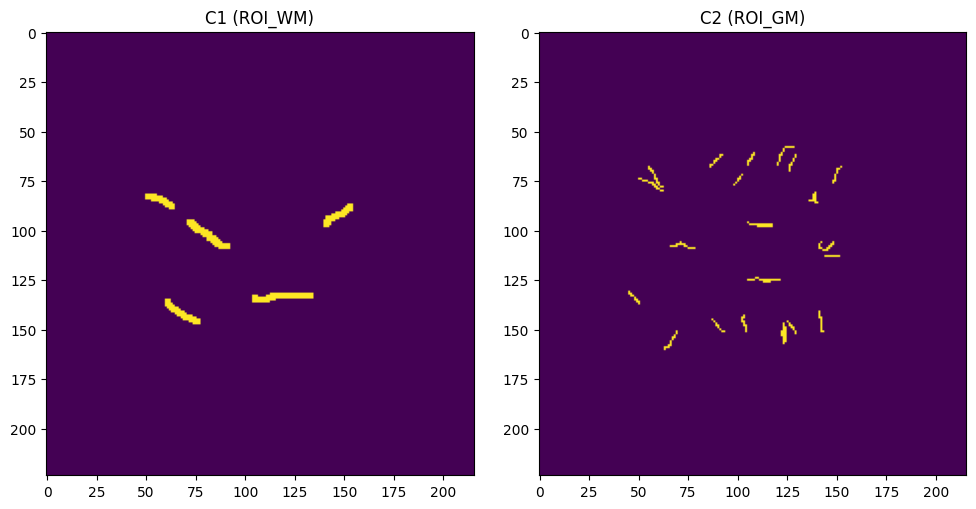

In [55]:
# prompt: Place trainings examples i.e. ROI_WM and ROI_GM into variables C1 and C2 representing class 1 and class 2 respectively. Show in a figure the manually expert drawings of the C1 and C2 training examples.

C1 = ROI_WM
C2 = ROI_GM

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(C1)
plt.title('C1 (ROI_WM)')

plt.subplot(1, 2, 2)
plt.imshow(C2)
plt.title('C2 (ROI_GM)')

plt.tight_layout()
plt.show()


In [56]:
WM_indexes = np.argwhere(C1)
GM_indexes = np.argwhere(C2)
print(WM_indexes.shape, GM_indexes.shape)


(399, 2) (280, 2)


What is the difference between the 1D histogram of the training examples and the 1D histogram of the whole image? Is the difference expected?

The 1D histogram of the training examples (GM and WM ROIs) shows the distribution of intensity values *within* those specific regions.  
The 1D histogram of the whole image shows the distribution of intensity values across *all* pixels in the image, including background, CSF, GM, and WM.

The difference is expected because the training examples are a *subset* of the image data.  
The histogram of the whole image will reflect the intensity distribution of all tissue types and background, whereas the training example histograms show only the intensities found within the GM and WM regions.  The whole image will have a broader range of intensities due to the inclusion of non-brain tissues (e.g. background, CSF) which have significantly different intensity values than GM or WM.


## LDA

In [57]:
import numpy as np

def LDA(X, y):
    """
    Linear Discriminant Analysis.

    A classifier with a linear decision boundary, generated by fitting class conditional densities to the data and using Bayes’ rule.
    Assumes equal priors among classes

    Parameters
    ----------
    X : array-like of shape (n_samples, n_features)
        Training data
    y : array-like of shape (n_samples,)
        Target values.

    Returns
    -------
    W : array-like of shape (n_classes, n_features+1)
        Weights for making the projection. First column is the constants.

    Last modified: 11/11/22, mcbo@dtu.dk
    """

    # Determine size of input data
    n, m = X.shape
    # Discover and count unique class labels
    class_label = np.unique(y)
    k = len(class_label)

    # Initialize
    n_group     = np.zeros((k,1))     # Group counts
    group_mean  = np.zeros((k,m))     # Group sample means
    pooled_cov  = np.zeros((m,m))     # Pooled covariance
    W          = np.zeros((k,m+1))    # Model coefficients

    for i in range(k):
        # Establish location and size of each class
        group      = np.squeeze(y == class_label[i])
        n_group[i]  = np.sum(group.astype(np.double))

        # Calculate group mean vectors
        group_mean[i,:] = np.mean(X[group,:], axis = 0)

        # Accumulate pooled covariance information
        pooled_cov = pooled_cov + ((n_group[i] - 1) / (n - k) ) * np.cov(X[group,:], rowvar = False)

    # Assign prior probabilities
    prior_prob = n_group / n

    # Loop over classes to calculate linear discriminant coefficients
    for i in range(k):
        # Intermediate calculation for efficiency
        temp = group_mean[i,:][np.newaxis] @ np.linalg.inv(pooled_cov)

        # Constant
        W[i,0] = -0.5 * temp @ group_mean[i,:].T + np.log(prior_prob[i])

        # Linear
        W[i,1:] = temp

    return W

Make a training data vector (X) and target class vector (T) as input for the LDA() function. T and X should have the same length of data points.

X: Training data vector should first include all data points for class 1 and then the data points for class 2. Data points are the two input features ImgT1, ImgT2

T: Target class identifier for X where '0' are Class 1 and a '1' is Class 2.

In [58]:
# Concatenate the feature vectors for each class
X = np.concatenate((np.column_stack((ImgT1[C1], ImgT2[C1])), np.column_stack((ImgT1[C2], ImgT2[C2]))))

# Create the target class vector T
T = np.concatenate((np.zeros(np.sum(C1)), np.ones(np.sum(C2))))

X.shape, T.shape

((679, 2), (679,))

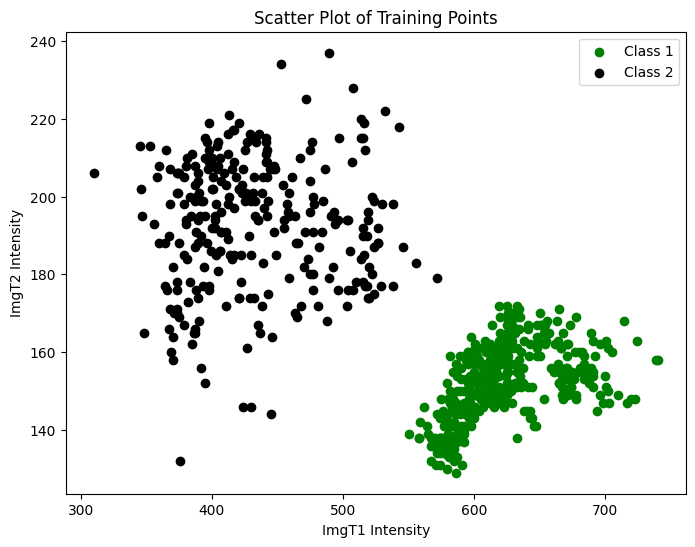

In [59]:
plt.figure(figsize=(8, 6))
plt.scatter(X[T == 0, 0], X[T == 0, 1], color='green', marker='o', label='Class 1')
plt.scatter(X[T == 1, 0], X[T == 1, 1], color='black', marker='o', label='Class 2')
plt.title('Scatter Plot of Training Points')
plt.xlabel('ImgT1 Intensity')
plt.ylabel('ImgT2 Intensity')
plt.legend()
plt.show()


In [60]:
W = LDA(X,T)
W

<ipython-input-57-f5ac5676fbdf>:57: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  W[i,0] = -0.5 * temp @ group_mean[i,:].T + np.log(prior_prob[i])


array([[-138.11536977,    0.27566672,    0.68044071],
       [-131.32787698,    0.15900268,    0.99568003]])

Apply the linear discriminant classifier i.e. perform multi-modal classification using the trained weight-vector
W for each class: It calculates the linear score Y for all image data points within the brain slice i.e. y(x)=w+w0
. Actually, y(x) is the log(P(Ci|x)).

In [66]:
Xall= np.c_[ImgT1.ravel(), ImgT2.ravel()]
Y = np.c_[np.ones((len(Xall), 1)), Xall] @ W.T
Xall.shape, Y.shape

((48384, 2), (48384, 2))

Perform multi-modal classification: Calculate the posterior probability i.e.
P(C1|X) of a data point belonging to class 1

Note: Using Bayes [Eq 1]: Since y(x) is the log of the posterior probability [Eq2] we take exp⁡(y(x)) to get P(C1|X)=P(X|μ,σ)P(C1)and divide with the marginal probability P(X) as normalisation factor.
Basically softmax

https://grok.com/share/bGVnYWN5_5bb4c7a4-74fb-4951-94a3-91175a57da59

In [70]:
PosteriorProb = np.clip(np.exp(Y) / np.sum(np.exp(Y), 1)[:, np.newaxis], 0, 1)
PosteriorProb.shape, PosteriorProb

((48384, 2),
 array([[0.00159784, 0.99840216],
        [0.00159784, 0.99840216],
        [0.00142215, 0.99857785],
        ...,
        [0.00159784, 0.99840216],
        [0.00159784, 0.99840216],
        [0.00112652, 0.99887348]]))

In [72]:
P_C1_X = PosteriorProb[:, 0]
P_C2_X = PosteriorProb[:, 1]
P_C1_X.shape, P_C2_X.shape

((48384,), (48384,))

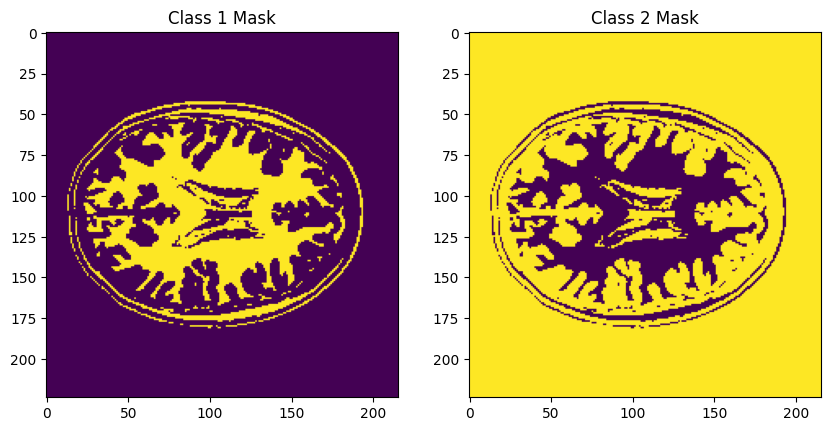

In [74]:
# Find voxels belonging to Class 1 (P(C1|X) > 0.5)
class1_voxels = np.where(P_C1_X.reshape(ImgT1.shape) > 0.5)

# Find voxels belonging to Class 2 (P(C2|X) > 0.5)
class2_voxels = np.where(P_C2_X.reshape(ImgT1.shape) > 0.5)

# You can now use class1_voxels and class2_voxels for further processing or visualization
# For example, to create a mask for class 1:
class1_mask = np.zeros_like(ImgT1, dtype=bool)
class1_mask[class1_voxels] = True

class2_mask = np.zeros_like(ImgT1, dtype=bool)
class2_mask[class2_voxels] = True

# Display the masks (optional)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(class1_mask)
plt.title('Class 1 Mask')

plt.subplot(1, 2, 2)
plt.imshow(class2_mask)
plt.title('Class 2 Mask')

plt.show()
